
# Fake News Detection with BERT and Explainability Analysis



In [ ]:

!pip install datasets transformers shap lime -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

from datasets import load_dataset

dataset = load_dataset("GonzaloA/fake_news")
print(dataset)

df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])

print(df_train.head())
print(df_train['label'].value_counts())
print(f"\n훈련 데이터 크기: {len(df_train)}")
print(f"테스트 데이터 크기: {len(df_test)}")


Using device: cuda


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/38.8M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/13.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/24353 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8117 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8117 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'title', 'text', 'label'],
        num_rows: 24353
    })
    validation: Dataset({
        features: ['Unnamed: 0', 'title', 'text', 'label'],
        num_rows: 8117
    })
    test: Dataset({
        features: ['Unnamed: 0', 'title', 'text', 'label'],
        num_rows: 8117
    })
})
   Unnamed: 0                                              title  \
0           0   ‘Maury’ Show Official Facebook Posts F*CKED U...   
1           1   Trump’s Favorite News Channel Tries To Soothe...   
2           2  Russia warns Iraq, Kurds not to destabilize Mi...   
3           3  WATCH STEVE SCALISE Throw A Strike At The Nati...   
4           4   Trump Will HATE What Stephen Colbert Just Did...   

                                                text  label  
0  Maury is perhaps one of the trashiest shows on...      0  
1  Yesterday, after the father of one of the UCLA...      0  
2  MOSCOW (Reuters) - Russia on Wednesday warned .

결측값:
Unnamed: 0    0
title         0
text          0
label         0
dtype: int64


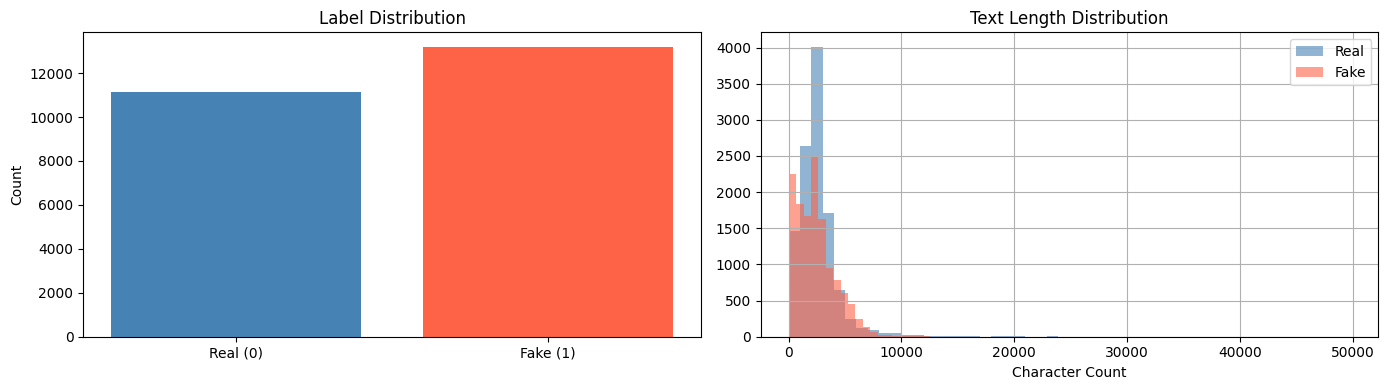


평균 텍스트 길이:
label
0    2645.818426
1    2473.114892
Name: text_len, dtype: float64


In [ ]:
# 결측값 확인
print("결측값:")
print(df_train.isnull().sum())

# 결측값 제거
df_train = df_train.dropna(subset=['title', 'text', 'label'])
df_test = df_test.dropna(subset=['title', 'text', 'label'])

# title + text 합쳐서 하나의 컬럼으로
df_train['content'] = df_train['title'] + ' ' + df_train['text']
df_test['content'] = df_test['title'] + ' ' + df_test['text']

# 텍스트 길이 분포
df_train['text_len'] = df_train['content'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 라벨 분포
axes[0].bar(['Real (0)', 'Fake (1)'], df_train['label'].value_counts().sort_index(), color=['steelblue', 'tomato'])
axes[0].set_title('Label Distribution')
axes[0].set_ylabel('Count')

# 텍스트 길이 분포
df_train[df_train['label']==0]['text_len'].hist(ax=axes[1], alpha=0.6, bins=50, color='steelblue', label='Real')
df_train[df_train['label']==1]['text_len'].hist(ax=axes[1], alpha=0.6, bins=50, color='tomato', label='Fake')
axes[1].set_title('Text Length Distribution')
axes[1].set_xlabel('Character Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n평균 텍스트 길이:")
print(df_train.groupby('label')['text_len'].mean())

=== TF-IDF + Logistic Regression ===
              precision    recall  f1-score   support

        Real       0.97      0.98      0.97      3782
        Fake       0.98      0.97      0.97      4335

    accuracy                           0.97      8117
   macro avg       0.97      0.97      0.97      8117
weighted avg       0.97      0.97      0.97      8117



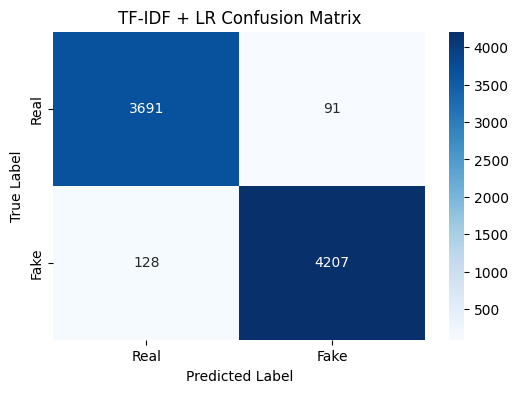

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# TF-IDF 벡터화
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2), sublinear_tf=True)
X_train = tfidf.fit_transform(df_train['content'])
X_test = tfidf.transform(df_test['content'])

y_train = df_train['label']
y_test = df_test['label']

# Logistic Regression
lr = LogisticRegression(max_iter=1000, C=1.0)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== TF-IDF + Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['Real', 'Fake']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('TF-IDF + LR Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import classification_report
import torch

# 데이터 샘플링 (T4 메모리 고려)
train_sample = df_train.sample(n=10000, random_state=42)
test_sample = df_test.sample(n=2000, random_state=42)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = FakeNewsDataset(train_sample['content'], train_sample['label'], tokenizer)
test_dataset = FakeNewsDataset(test_sample['content'], test_sample['label'], tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

# 모델
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
model = model.to(device)

# 옵티마이저 & 스케줄러
optimizer = AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_loader) * 3
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

print("설정 완료! 학습 시작 준비됐어요.")
print(f"훈련 샘플: {len(train_sample)}, 테스트 샘플: {len(test_sample)}")
print(f"배치당 스텝 수: {len(train_loader)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


설정 완료! 학습 시작 준비됐어요.
훈련 샘플: 10000, 테스트 샘플: 2000
배치당 스텝 수: 625


In [ ]:
# 학습 함수
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    return total_loss / len(loader)

# 평가 함수
def evaluate(model, loader, device):
    model.eval()
    preds, true_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    return preds, true_labels

# 학습 루프 (3 epochs)
for epoch in range(3):
    avg_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    preds, true_labels = evaluate(model, test_loader, device)
    print(f"\nEpoch {epoch+1}/3 | Loss: {avg_loss:.4f}")
    print(classification_report(true_labels, preds, target_names=['Real', 'Fake']))


Epoch 1/3 | Loss: 0.0602
              precision    recall  f1-score   support

        Real       0.99      0.98      0.99       945
        Fake       0.98      1.00      0.99      1055

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000


Epoch 2/3 | Loss: 0.0300
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99       945
        Fake       0.99      0.99      0.99      1055

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000


Epoch 3/3 | Loss: 0.0103
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99       945
        Fake       0.99      0.99      0.99      1055

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2

In [ ]:
import os

# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

# 저장 경로
save_path = '/content/drive/MyDrive/fakenews_bert'
os.makedirs(save_path, exist_ok=True)

# 모델 & 토크나이저 저장
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

# 데이터 저장
train_sample.to_csv(f'{save_path}/train_sample.csv', index=False)
test_sample.to_csv(f'{save_path}/test_sample.csv', index=False)

print(f"저장 완료! 경로: {save_path}")


Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

저장 완료! 경로: /content/drive/MyDrive/fakenews_bert


In [ ]:
import shap
import transformers

# SHAP용 파이프라인 생성
pipe = transformers.pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0,
    return_all_scores=True
)

# 샘플 텍스트 준비 (진짜 5개, 가짜 5개)
real_samples = test_sample[test_sample['label']==0]['content'].head(5).tolist()
fake_samples = test_sample[test_sample['label']==1]['content'].head(5).tolist()
samples = real_samples + fake_samples

# 텍스트 길이 제한 (SHAP 속도 위해)
samples = [s[:512] for s in samples]

# SHAP explainer
explainer = shap.Explainer(pipe)
shap_values = explainer(samples)

print("SHAP 계산 완료!")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  10%|█         | 1/10 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  30%|███       | 3/10 [00:15<00:18,  2.60s/it]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 10/10 [01:14<00:00,  9.80s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [01:21,  8.13s/it]

SHAP 계산 완료!


In [ ]:
# 전체 테스트셋에서 오분류 케이스 추출
model.eval()
all_preds, all_labels, all_texts = [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_sample_reset = test_sample.reset_index(drop=True)
test_sample_reset['pred'] = all_preds
test_sample_reset['true'] = all_labels

# 오분류 케이스
misclassified = test_sample_reset[test_sample_reset['pred'] != test_sample_reset['true']]
print(f"전체 테스트: {len(test_sample_reset)}개")
print(f"오분류: {len(misclassified)}개 ({len(misclassified)/len(test_sample_reset)*100:.1f}%)")
print(f"\n오분류 유형:")
print(f"진짜->가짜 (False Positive): {len(misclassified[misclassified['true']==0])}개")
print(f"가짜->진짜 (False Negative): {len(misclassified[misclassified['true']==1])}개")

# 오분류 샘플 확인
print("\n=== 오분류 샘플 예시 ===")
for _, row in misclassified.head(3).iterrows():
    print(f"\n실제: {'Real' if row['true']==0 else 'Fake'} | 예측: {'Real' if row['pred']==0 else 'Fake'}")
    print(f"텍스트: {row['content'][:300]}...")
    print("-"*50)


전체 테스트: 2000개
오분류: 21개 (1.1%)

오분류 유형:
진짜->가짜 (False Positive): 7개
가짜->진짜 (False Negative): 14개

=== 오분류 샘플 예시 ===

실제: Real | 예측: Fake
텍스트: isis executes  civilians by electrocution in central mosul abdullah muhammad almuhaysini a senior al qaedalinked cleric and the religious leader of jeish alfatah terrorist group admitted that the militants in syria have received financial and military aid from saudi arabia and certain other persian ...
--------------------------------------------------

실제: Real | 예측: Fake
텍스트: eu red scare brussels passes new resolution to counter russian media propaganda  share the amish in america have committed their vote to donald trump guaranteeing him the presidency ap photo  dennis system 
columbus oh ap  history was made today in columbus ohio when more than  million amish poured ...
--------------------------------------------------

실제: Fake | 예측: Real
텍스트: watch beyoncé tell the entire world why she supports hillary grab your tissues video on november 

In [ ]:
# 오분류 패턴 분석
from collections import Counter
import re

def get_top_words(texts, n=20):
    words = []
    for text in texts:
        words.extend(re.findall(r'\b[a-zA-Z]{4,}\b', text.lower()))
    stopwords = {'that', 'this', 'with', 'have', 'from', 'they', 'will', 'been', 'were', 'when', 'what', 'said', 'about', 'would', 'their', 'there', 'which', 'also'}
    words = [w for w in words if w not in stopwords]
    return Counter(words).most_common(n)

fp_texts = misclassified[misclassified['true']==0]['content'].tolist()
fn_texts = misclassified[misclassified['true']==1]['content'].tolist()

print("=== 진짜->가짜 오분류에서 자주 나온 단어 (False Positive) ===")
for word, count in get_top_words(fp_texts):
    print(f"  {word}: {count}")

print("\n=== 가짜->진짜 오분류에서 자주 나온 단어 (False Negative) ===")
for word, count in get_top_words(fn_texts):
    print(f"  {word}: {count}")

# 오분류 vs 정분류 텍스트 길이 비교
correct = test_sample_reset[test_sample_reset['pred'] == test_sample_reset['true']]

print(f"\n=== 텍스트 길이 비교 ===")
print(f"정분류 평균 길이: {correct['content'].apply(len).mean():.0f}")
print(f"오분류 평균 길이: {misclassified['content'].apply(len).mean():.0f}")

print(f"\n오분류 중 짧은 텍스트 (1000자 미만): {len(misclassified[misclassified['content'].apply(len) < 1000])}개")
print(f"오분류 중 긴 텍스트 (1000자 이상): {len(misclassified[misclassified['content'].apply(len) >= 1000])}개")


=== 진짜->가짜 오분류에서 자주 나온 단어 (False Positive) ===
  trump: 40
  clinton: 33
  hillary: 21
  more: 17
  assange: 17
  states: 15
  amish: 15
  donald: 14
  against: 13
  than: 13
  election: 13
  many: 12
  political: 11
  wikileaks: 11
  times: 11
  other: 10
  into: 10
  november: 9
  campaign: 9
  guns: 9

=== 가짜->진짜 오분류에서 자주 나온 단어 (False Negative) ===
  clinton: 34
  pipeline: 23
  hillary: 19
  band: 19
  jihad: 18
  trump: 17
  people: 17
  over: 16
  bill: 15
  election: 13
  more: 13
  according: 13
  explosion: 13
  just: 12
  million: 12
  into: 12
  foundation: 11
  those: 11
  president: 11
  teneo: 11

=== 텍스트 길이 비교 ===
정분류 평균 길이: 2556
오분류 평균 길이: 3093

오분류 중 짧은 텍스트 (1000자 미만): 4개
오분류 중 긴 텍스트 (1000자 이상): 17개


/tmp/ipykernel_3203/2349051445.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(length_data.values(), labels=length_data.keys())


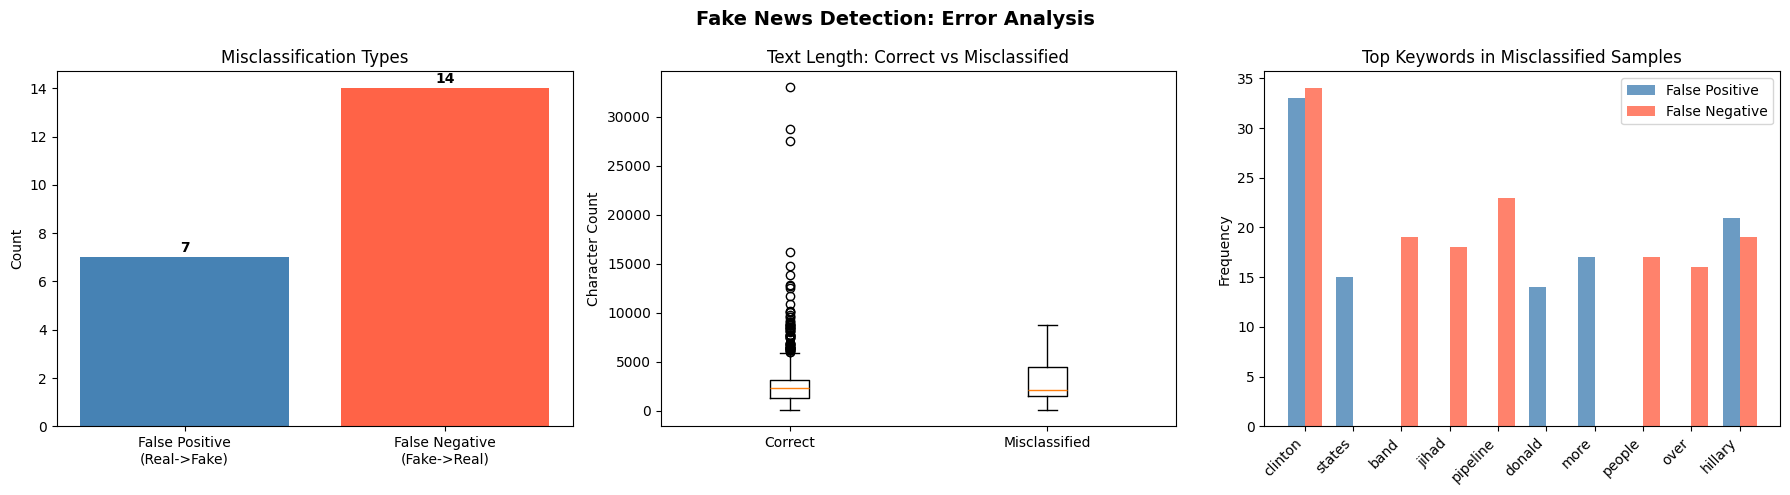


=== 최종 요약 ===
TF-IDF + LR 정확도: 97%
BERT 정확도: 99%
오분류 21개 중 정치 관련 키워드 포함 비율: 76%
오분류 평균 텍스트 길이: 3093자 (정분류 대비 +537자)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. 오분류 유형 비교
categories = ['False Positive\n(Real->Fake)', 'False Negative\n(Fake->Real)']
counts = [7, 14]
colors = ['steelblue', 'tomato']
axes[0].bar(categories, counts, color=colors)
axes[0].set_title('Misclassification Types')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

# 2. 텍스트 길이 비교
length_data = {
    'Correct': correct['content'].apply(len).values,
    'Misclassified': misclassified['content'].apply(len).values
}
axes[1].boxplot(length_data.values(), labels=length_data.keys())
axes[1].set_title('Text Length: Correct vs Misclassified')
axes[1].set_ylabel('Character Count')

# 3. 상위 키워드 비교
fp_words = dict(get_top_words(fp_texts, 8))
fn_words = dict(get_top_words(fn_texts, 8))
all_words = list(set(list(fp_words.keys()) + list(fn_words.keys())))[:10]

x = np.arange(len(all_words))
width = 0.35
fp_vals = [fp_words.get(w, 0) for w in all_words]
fn_vals = [fn_words.get(w, 0) for w in all_words]

axes[2].bar(x - width/2, fp_vals, width, label='False Positive', color='steelblue', alpha=0.8)
axes[2].bar(x + width/2, fn_vals, width, label='False Negative', color='tomato', alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(all_words, rotation=45, ha='right')
axes[2].set_title('Top Keywords in Misclassified Samples')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.suptitle('Fake News Detection: Error Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== 최종 요약 ===")
print(f"TF-IDF + LR 정확도: 97%")
print(f"BERT 정확도: 99%")
print(f"오분류 21개 중 정치 관련 키워드 포함 비율: {sum(1 for t in misclassified['content'] if any(w in t.lower() for w in ['trump', 'clinton', 'hillary', 'election']))/len(misclassified)*100:.0f}%")
print(f"오분류 평균 텍스트 길이: {misclassified['content'].apply(len).mean():.0f}자 (정분류 대비 +{misclassified['content'].apply(len).mean() - correct['content'].apply(len).mean():.0f}자)")

In [ ]:
# 1. 오분류 분석 결과 CSV 저장
misclassified.to_csv('/content/drive/MyDrive/fakenews_bert/misclassified_analysis.csv', index=False)
test_sample_reset.to_csv('/content/drive/MyDrive/fakenews_bert/test_results.csv', index=False)

# 2. 시각화 이미지 저장
fig.savefig('/content/drive/MyDrive/fakenews_bert/error_analysis.png', dpi=150, bbox_inches='tight')

# 3. 결과 요약 텍스트 저장
summary = f"""
=== Fake News Detection Project Summary ===

Dataset: GonzaloA/fake_news
Train: 10,000 samples / Test: 2,000 samples

Model Comparison:
- TF-IDF + Logistic Regression: 97% accuracy
- BERT fine-tuned: 99% accuracy

Error Analysis (21 misclassified):
- False Positive (Real->Fake): 7
- False Negative (Fake->Real): 14
- Average text length (correct): {correct['content'].apply(len).mean():.0f}
- Average text length (misclassified): {misclassified['content'].apply(len).mean():.0f}

Key Findings:
- Political content (trump, clinton, election) shows higher misclassification rate
- Fake news using professional vocabulary tends to evade detection
- Longer texts are harder to classify correctly
- Model shows lexical bias over contextual understanding
"""

with open('/content/drive/MyDrive/fakenews_bert/summary.txt', 'w') as f:
    f.write(summary)

print("모두 저장 완료!")
print("저장 위치: Google Drive > fakenews_bert 폴더")

모두 저장 완료!
저장 위치: Google Drive > fakenews_bert 폴더
